# 4b. Despliegue de su modelo


In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import torchvision.io as tv_io
import torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt

import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

## 4b.2 Cargando el Modelo


In [2]:
!apt-get install -y p7zip-full
!wget https://github.com/JuanAraca/MNIST/raw/main/MNIST_NUM1.7z -O MNIST_NUM1.7z
!7z x MNIST_NUM1.7z
!rm -f MNIST_NUM1.7z
!rm -f sign_mnist_train.csv
!rm -f sign_mnist_valid.csv

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
--2025-05-02 03:13:17--  https://github.com/JuanAraca/MNIST/raw/main/MNIST_NUM1.7z
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/JuanAraca/MNIST/main/MNIST_NUM1.7z [following]
--2025-05-02 03:13:18--  https://raw.githubusercontent.com/JuanAraca/MNIST/main/MNIST_NUM1.7z
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14173970 (14M) [application/octet-stream]
Saving to: ‘MNIST_

In [3]:
from utils import MyConvBlock

In [4]:
model = torch.load('model.pth', map_location=device, weights_only=False)
model

OptimizedModule(
  (_orig_mod): Sequential(
    (0): Conv2d(1, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(25, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(50, 75, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (13): Flatten(start_dim=1, end_dim=-1)
    (14): Linear(in_features=675, out_features=512, bias=True)
    (15): Dropout

## 1.2 El conjunto de datos MNIST

In [5]:
train_set = torchvision.datasets.MNIST("./data/", train=True, download=True)
valid_set = torchvision.datasets.MNIST("./data/", train=False, download=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.76MB/s]


In [6]:
train_set

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data/
    Split: Train

In [7]:
valid_set

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data/
    Split: Test

### 1.2.3 Exploración de los datos MNIST


In [8]:
x_0, y_0 = train_set[0]

In [9]:
x_0

In [10]:
type(x_0)

PIL.Image.Image

In [11]:
y_0

5

In [12]:
type(y_0)

int

In [13]:
x_0.size

(28, 28)

### 4b.3.1 Mostrar las imágenes

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_image(image_path):
    image = mpimg.imread(image_path)
    plt.imshow(image, cmap='gray')

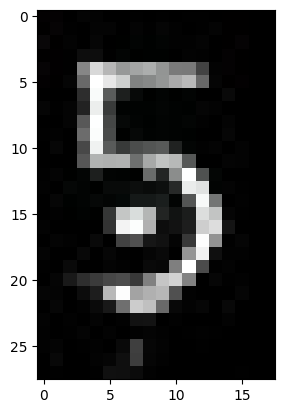

In [65]:
show_image('ruido/5.jpg')

### 4b.3.2 Escalado de las imágenes

In [72]:
image = tv_io.read_image('ruido/5.jpg', tv_io.ImageReadMode.GRAY)
image

tensor([[[  2,   3,   0,   4,   3,   0,   0,   1,   0,   1,   0,   1,   1,   0,
            0,   0,   0,   0],
         [  0,   5,   1,   0,   4,   4,   0,   4,   1,   5,   2,   0,   1,   4,
            0,   0,   0,   0],
         [  8,   0,   3,   0,   6,   0,   0,   3,   1,   3,   2,   2,   4,   0,
            0,   4,   0,   0],
         [  0,   1,   1,  13,  13,   1,   4,   0,   1,   1,   0,   3,   2,   0,
            3,   0,   0,   0],
         [  5,   1,   1, 134, 216, 182, 152, 164, 173, 148, 122, 121,  67,   3,
            3,   0,   0,   0],
         [  2,   0,   5, 105, 255, 231, 206, 130, 136, 149, 170, 185, 104,   5,
            0,   2,   0,   0],
         [  0,   0,   0,  45, 250,  91,  30,   8,   0,   3,   0,   3,   0,   0,
            9,   0,   0,   0],
         [  5,   1,   4,  34, 237,  58,   2,   2,   2,   4,   2,   1,   5,   3,
            0,   0,   0,   0],
         [  0,   0,   4,  88, 255,  70,   7,   3,   1,   3,   2,   4,   2,   0,
            4,   0,   0,   0],
 

In [73]:
image.shape

torch.Size([1, 28, 18])

## 2.5 Construir el modelo

In [74]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHS = 1

preprocess_trans = transforms.Compose([
    transforms.ToDtype(torch.float32, scale=True), # Converts [0, 255] to [0, 1]
    transforms.Resize((IMG_WIDTH, IMG_HEIGHT)),
    transforms.Grayscale()  # From Color to Gray
])

In [75]:
processed_image = preprocess_trans(image)
processed_image

tensor([[[7.8431e-03, 9.6639e-03, 1.0504e-02, 2.9412e-03, 6.1625e-03,
          1.5546e-02, 1.3025e-02, 7.9832e-03, 4.2017e-04, 0.0000e+00,
          9.8039e-04, 3.5014e-03, 1.8207e-03, 7.0028e-04, 3.2213e-03,
          2.1008e-03, 4.2017e-04, 2.9412e-03, 3.9216e-03, 3.7815e-03,
          1.2605e-03, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 9.1036e-03, 1.7927e-02, 7.8431e-03, 2.3810e-03,
          5.6022e-04, 1.0644e-02, 1.5686e-02, 1.5686e-02, 6.1625e-03,
          3.9216e-03, 1.4006e-02, 9.3838e-03, 6.7227e-03, 1.6807e-02,
          1.4146e-02, 7.0028e-03, 1.9608e-03, 1.5406e-03, 4.3417e-03,
          1.1905e-02, 1.0644e-02, 5.6022e-04, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 0.0000e+00],
         [3.1373e-02, 1.6807e-02, 1.2605e-03, 8.8235e-03, 7.1429e-03,
          8.4033e-04, 1.5966e-02, 1.5966e-02, 8.4033e-04, 0.0000e+00,
          2.9412e-03, 1.0504e-02, 7.5630e-03, 5.3221e-03, 1.0364e-

In [76]:
processed_image.shape

torch.Size([1, 28, 28])

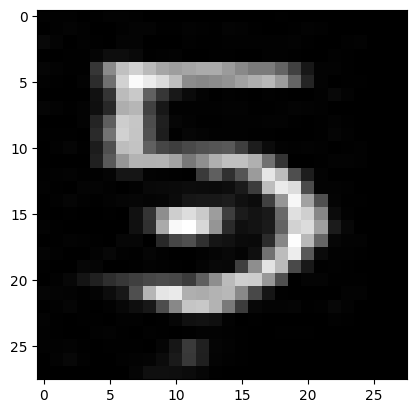

In [77]:
plot_image = F.to_pil_image(processed_image)
plt.imshow(plot_image, cmap='gray')

### 4b.4 Hacer predicciones

In [78]:
batched_image = processed_image.unsqueeze(0)
batched_image.shape

batched_image_gpu = batched_image.to(device)
batched_image_gpu.device

output = model(batched_image_gpu)
output

tensor([[-6.6432, -3.7005, -7.5710,  3.0774, -9.2736,  5.7270, -5.7413, -3.3597,
         -4.3579, -2.5746]], device='cuda:0',
       grad_fn=<CompiledFunctionBackward>)

### 3.2.2 Crear un conjunto de datos

In [79]:
class MyDataset(Dataset):
    def __init__(self, base_dataset):
        x_ds = base_dataset.data.float()
        y_ds = base_dataset.targets
        x_ds = x_ds / 255.0
        x_ds = x_ds.unsqueeze(1)
        x_ds = x_ds.reshape(-1, IMG_CHS, IMG_HEIGHT, IMG_WIDTH)
        self.xs = x_ds.to(device)
        self.ys = y_ds.to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

### 3.2.3 Crear un DataLoader

In [80]:
BATCH_SIZE = 32

train_data = MyDataset(train_set)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
train_N = len(train_loader.dataset)

valid_data = MyDataset(valid_set)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False)
valid_N = len(valid_loader.dataset)

In [25]:
batch = next(iter(train_loader))
batch

[tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         ...,
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ..

In [81]:
batch[0].shape

torch.Size([32, 1, 28, 28])

In [82]:
batch[1].shape

torch.Size([32])

### 4b.4.1 Comprender la predicción

In [83]:
prediction = output.argmax(dim=1).item()
prediction

5

In [84]:
# Alphabet does not contain j or z because they require movement
number = "0123456789"

In [85]:
number[prediction]

'5'

In [86]:
def predicted_number(file_path):
    # Show image
    show_image(file_path)
    # Load and grayscale image
    image = tv_io.read_image(file_path, tv_io.ImageReadMode.GRAY)
    # Transform image
    image = preprocess_trans(image)
    # Batch image
    image = image.unsqueeze(0)
    # Send image to correct device
    image = image.to(device)
    # Make prediction
    output = model(image)
    # Find max index
    prediction = output.argmax(dim=1).item()
    # Convert prediction to letter
    predicted_number = number[prediction]
    # Return prediction
    return predicted_number

'5'

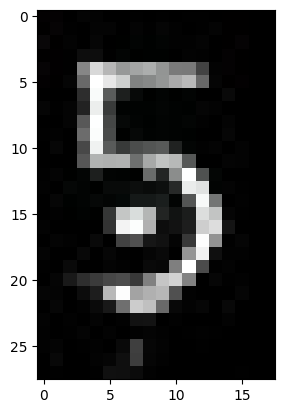

In [88]:
# En todas las carpetas hay imagenes del 0 - 9
predicted_number("ruido/5.jpg")

## 3.3 Crear un modelo convolucional

In [89]:
n_classes = 10
kernel_size = 3
flattened_img_size = 75 * 3 * 3

model = nn.Sequential(
    # First convolution
    nn.Conv2d(IMG_CHS, 25, kernel_size, stride=1, padding=1),  # 25 x 28 x 28
    nn.BatchNorm2d(25),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14
    # Second convolution
    nn.Conv2d(25, 50, kernel_size, stride=1, padding=1),  # 50 x 14 x 14
    nn.BatchNorm2d(50),
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7
    # Third convolution
    nn.Conv2d(50, 75, kernel_size, stride=1, padding=1),  # 75 x 7 x 7
    nn.BatchNorm2d(75),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3
    # Flatten to Dense
    nn.Flatten(),
    nn.Linear(flattened_img_size, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, n_classes)
)

In [90]:
model = torch.compile(model.to(device))

In [91]:
model

OptimizedModule(
  (_orig_mod): Sequential(
    (0): Conv2d(1, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(25, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(50, 75, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (13): Flatten(start_dim=1, end_dim=-1)
    (14): Linear(in_features=675, out_features=512, bias=True)
    (15): Dropout

## 1.6 Entrenamiento del modelo

### 1.6.1 Pérdidas y optimización

In [92]:
loss_function = nn.CrossEntropyLoss()

In [93]:
optimizer = Adam(model.parameters())

### 1.6.2 Cálculo de la Exactitud


In [94]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

### 1.6.3 La función Train

In [95]:
def train():
    loss = 0
    accuracy = 0

    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        output = model(x)
        optimizer.zero_grad()
        batch_loss = loss_function(output, y)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss.item()
        accuracy += get_batch_accuracy(output, y, train_N)
    print('Train - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

### 1.6.4 La función Validar

In [96]:
def validate():
    loss = 0
    accuracy = 0

    model.eval()
    with torch.no_grad():
        for x, y in valid_loader:
            x, y = x.to(device), y.to(device)
            output = model(x)

            loss += loss_function(output, y).item()
            accuracy += get_batch_accuracy(output, y, valid_N)
    print('Valid - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

### 1.6.5 El bucle de entrenamiento

In [97]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True

epochs = 5

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch))
    train()
    validate()

Epoch: 0
Train - Loss: 216.7429 Accuracy: 0.9639
Valid - Loss: 14.2506 Accuracy: 0.9845
Epoch: 1
Train - Loss: 91.0336 Accuracy: 0.9844
Valid - Loss: 10.4718 Accuracy: 0.9893
Epoch: 2
Train - Loss: 68.4946 Accuracy: 0.9889
Valid - Loss: 6.8652 Accuracy: 0.9923
Epoch: 3
Train - Loss: 55.1582 Accuracy: 0.9910
Valid - Loss: 7.6914 Accuracy: 0.9920
Epoch: 4
Train - Loss: 46.3827 Accuracy: 0.9925
Valid - Loss: 7.7842 Accuracy: 0.9927


In [52]:
torch.save(model, 'model.pth')